# New maze results:
Only show results.
The code for training/ generation/ plotting are not updated, as I'm still tweaking the image branch of the code. 

In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results import * 
import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
colorgrad = "PuOr"

# 1. Read Data

In [3]:
folder_data = 'data/mc_maze3'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
# np.sum(trial_idx_use)

# 2. Behavior Data

In [5]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

# 3. Model Generations

8 models:
1. latent dim  = 3, lag = 0
2. latent dim  = 3, lag = 5
3. latent dim  = 3, lag = 10, 
4. latent dim  = 3, lag = 10, re-constrt loss weight = 1 (smaller, previous = 20)
5. latent dim  = 3, lag = 10, re-constrt loss weight = 0
6. latent dim  = 5, lag = 5
7. latent dim  = 5, lag = 10
8. latent dim  = 1, lag  =10

In [6]:
dt = 0.001
eps_clamp = 1e-2
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps_clamp, max_value + eps_clamp]) # give some space

# version 2: clamp dim-by-dim (results are similar)
T_max = max(arr.shape[0] for arr in dset_samples)
padded_arrays = [np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)),
                        mode='constant', constant_values=np.nan) 
                 for arr in dset_samples]
stacked = np.stack(padded_arrays, axis=0)  # Shape [n_trial, T_max, dim]


min_vals = np.nanmin(stacked, axis=(0, 1))  # Shape [dim]
max_vals = np.nanmax(stacked, axis=(0, 1))  # Shape [dim]

clamp_range = np.stack([min_vals, max_vals], axis=1)  # Shape [dim, 2]
clamp_range[:,0] = clamp_range[:,0] - eps_clamp
clamp_range[:,1] = clamp_range[:,1] + eps_clamp

In [7]:
chk_pts = '/network-snapshot-500000.pkl'
# chk_pts = '/network-snapshot-471654.pkl'

In [8]:
folder_data = 'out/maze/dim3_lag0/data'
folder = 'out/maze/dim3_lag0/00000-maze_dim3_lag0-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 3
dset_samples_3_0, lag_samples_3_0,\
flow_net_3_0, dyn_net_3_0, encoder_3_0,\
d_3_0, L_3_0, loading_3_0, traj_sim_tau1_3_0, traj_sim_tau0_3_0 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 0
traj_sim_tau1_comp_3_0 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_0[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_0 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_0[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 99/99 [00:00<00:00, 147.17it/s]


project starting points to latent


100%|██████████████████████████████████████████| 99/99 [00:00<00:00, 139.55it/s]


In [9]:
folder_data = 'out/maze/dim3_lag5/data'
folder = 'out/maze/dim3_lag5/00000-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-431513.pkl'
dim_preserve = 3
dset_samples_3_5, lag_samples_3_5,\
flow_net_3_5, dyn_net_3_5, encoder_3_5,\
d_3_5, L_3_5, loading_3_5, traj_sim_tau1_3_5, traj_sim_tau0_3_5 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 5
traj_sim_tau1_comp_3_5 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_5[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_5 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_5[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 145.22it/s]


project starting points to latent


100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 142.51it/s]


In [10]:
folder_data = 'out/maze/dim3_lag10/data'
folder = 'out/maze/dim3_lag10/00000-maze_dim3_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 3
dset_samples_3_10, lag_samples_3_10,\
flow_net_3_10, dyn_net_3_10, encoder_3_10,\
d_3_10, L_3_10, loading_3_10, traj_sim_tau1_3_10, traj_sim_tau0_3_10 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_3_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_10[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_10[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 114.97it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 131.02it/s]


In [11]:
folder_data = 'out/maze/dim3_lag10_eta1/data'
folder = 'out/maze/dim3_lag10_eta1/00000-maze_dim3_lag10_eta1-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 3
dset_samples_3_10_eta1, lag_samples_3_10_eta1,\
flow_net_3_10_eta1, dyn_net_3_10_eta1, encoder_3_10_eta1,\
d_3_10_eta1, L_3_10_eta1, loading_3_10_eta1, traj_sim_tau1_3_10_eta1, traj_sim_tau0_3_10_eta1 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_3_10_eta1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_10_eta1[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_10_eta1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_10_eta1[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 155.20it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 132.55it/s]


In [12]:
folder_data = 'out/maze/dim3_lag10_nore/data'
folder = 'out/maze/dim3_lag10_nore/00000-maze_dim3_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 3
dset_samples_3_10_nore, lag_samples_3_10_nore,\
flow_net_3_10_nore, dyn_net_3_10_nore, encoder_3_10_nore,\
d_3_10_nore, L_3_10_nore, loading_3_10_nore, traj_sim_tau1_3_10_nore, traj_sim_tau0_3_10_nore =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_3_10_nore = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_10_nore[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_10_nore = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_10_nore[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 146.83it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 150.31it/s]


In [13]:
folder_data = 'out/maze/dim5_lag5/data'
folder = 'out/maze/dim5_lag5/00000-maze_dim5_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 5
dset_samples_5_5, lag_samples_5_5,\
flow_net_5_5, dyn_net_5_5, encoder_5_5,\
d_5_5, L_5_5, loading_5_5, traj_sim_tau1_5_5, traj_sim_tau0_5_5 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 5
traj_sim_tau1_comp_5_5 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_5_5[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_5_5 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_5_5[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 158.42it/s]


project starting points to latent


100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 153.61it/s]


In [14]:
folder_data = 'out/maze/dim5_lag10/data'
folder = 'out/maze/dim5_lag10/00000-maze_dim5_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 5
dset_samples_5_10, lag_samples_5_10,\
flow_net_5_10, dyn_net_5_10, encoder_5_10,\
d_5_10, L_5_10, loading_5_10, traj_sim_tau1_5_10, traj_sim_tau0_5_10 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_5_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_5_10[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_5_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_5_10[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 142.37it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 146.71it/s]


In [15]:
folder_data = 'out/maze/dim1_lag10/data'
folder = 'out/maze/dim1_lag10/00000-maze_dim1_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-461619.pkl' # this one is almost done

dim_preserve = 1
dset_samples_1_10, lag_samples_1_10,\
flow_net_1_10, dyn_net_1_10, encoder_1_10,\
d_1_10, L_1_10, loading_1_10, traj_sim_tau1_1_10, traj_sim_tau0_1_10 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_1_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_1_10[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_1_10 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_1_10[j])) for j in range(len(dset_samples))]

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 157.70it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 128.69it/s]


# 4. Check Fitting

## MSE

In [16]:
# tau = 1.0
overall_mse_tau1_3_0, per_trial_tau1_3_0,\
overall_mse_dim_tau1_3_0, per_trial_dim_tau1_3_0 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3_0)
overall_mse_tau1_3_5, per_trial_tau1_3_5,\
overall_mse_dim_tau1_3_5, per_trial_dim_tau1_3_5 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3_5)
overall_mse_tau1_3_10, per_trial_tau1_3_10,\
overall_mse_dim_tau1_3_10, per_trial_dim_tau1_3_10 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3_10)
overall_mse_tau1_3_10_eta1, per_trial_tau1_3_10_eta1,\
overall_mse_dim_tau1_3_10_eta1, per_trial_dim_tau1_3_10_eta1 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3_10_eta1)
overall_mse_tau1_3_10_nore, per_trial_tau1_3_10_nore,\
overall_mse_dim_tau1_3_10_nore, per_trial_dim_tau1_3_10_nore = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3_10_nore)
overall_mse_tau1_5_5, per_trial_tau1_5_5,\
overall_mse_dim_tau1_5_5, per_trial_dim_tau1_5_5 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_5_5)
overall_mse_tau1_5_10, per_trial_tau1_5_10,\
overall_mse_dim_tau1_5_10, per_trial_dim_tau1_5_10 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_5_10)
overall_mse_tau1_1_10, per_trial_tau1_1_10,\
overall_mse_dim_tau1_1_10, per_trial_dim_tau1_1_10 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_1_10)

# tau = 0.0
overall_mse_tau0_3_0, per_trial_tau0_3_0,\
overall_mse_dim_tau0_3_0, per_trial_dim_tau0_3_0 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3_0)
overall_mse_tau0_3_5, per_trial_tau0_3_5,\
overall_mse_dim_tau0_3_5, per_trial_dim_tau0_3_5 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3_5)
overall_mse_tau0_3_10, per_trial_tau0_3_10,\
overall_mse_dim_tau0_3_10, per_trial_dim_tau0_3_10 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3_10)
overall_mse_tau0_3_10_eta1, per_trial_tau0_3_10_eta1,\
overall_mse_dim_tau0_3_10_eta1, per_trial_dim_tau0_3_10_eta1 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3_10_eta1)
overall_mse_tau0_3_10_nore, per_trial_tau0_3_10_nore,\
overall_mse_dim_tau0_3_10_nore, per_trial_dim_tau0_3_10_nore = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3_10_nore)
overall_mse_tau0_5_5, per_trial_tau0_5_5,\
overall_mse_dim_tau0_5_5, per_trial_dim_tau0_5_5 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_5_5)
overall_mse_tau0_5_10, per_trial_tau0_5_10,\
overall_mse_dim_tau0_5_10, per_trial_dim_tau0_5_10 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_5_10)
overall_mse_tau0_1_10, per_trial_tau0_1_10,\
overall_mse_dim_tau0_1_10, per_trial_dim_tau0_1_10 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_1_10)

In [17]:
tensors = []
d_dim_toshow = 8
tensors.append(d_3_0[0:d_dim_toshow].cpu().numpy())
tensors.append(d_3_5[0:d_dim_toshow].cpu().numpy())
tensors.append(d_3_10[0:d_dim_toshow].cpu().numpy())
tensors.append(d_3_10_eta1[0:d_dim_toshow].cpu().numpy())
tensors.append(d_3_10_nore[0:d_dim_toshow].cpu().numpy())
tensors.append(d_5_5[0:d_dim_toshow].cpu().numpy())
tensors.append(d_5_10[0:d_dim_toshow].cpu().numpy())
tensors.append(d_1_10[0:d_dim_toshow].cpu().numpy())

model_names = ['dim 3, lag 0', 'dim 3, lag 5', 'dim 3, lag 10', 'dim 3, lag 10, small L_recon',
               'dim 3, lag 10, no L_recon', 'dim 5, lag 5', 'dim 5, lag 10', 'dim 1, lag 10']

In [18]:
data = {
    'model': model_names,
    'tau = 0.0': [overall_mse_tau0_3_0, overall_mse_tau0_3_5, overall_mse_tau0_3_10,
                  overall_mse_tau0_3_10_eta1, overall_mse_tau0_3_10_nore, overall_mse_tau0_5_5,
                  overall_mse_tau0_5_10, overall_mse_tau0_1_10],
    'tau = 1.0': [overall_mse_tau1_3_0, overall_mse_tau1_3_5, overall_mse_tau1_3_10,
                  overall_mse_tau1_3_10_eta1, overall_mse_tau1_3_10_nore, overall_mse_tau1_5_5,
                  overall_mse_tau1_5_10, overall_mse_tau1_1_10],
}

df = pd.DataFrame(data)
df.style.set_caption("MSE over trial").format(precision=5)

,model,tau = 0.0,tau = 1.0
0,"dim 3, lag 0",0.00097,0.00083
1,"dim 3, lag 5",0.00084,0.00076
2,"dim 3, lag 10",0.00072,0.00042
3,"dim 3, lag 10, small L_recon",0.00079,0.00049
4,"dim 3, lag 10, no L_recon",0.00181,0.00017
5,"dim 5, lag 5",0.00083,0.00085
6,"dim 5, lag 10",0.00073,0.00061
7,"dim 1, lag 10",0.00081,0.00031


In [19]:
columns = [f"d{i+1}" for i in range(tensors[0].shape[0])]
index = model_names
df = pd.DataFrame(tensors, index=index, columns=columns)
df.style.set_caption("eigen values: the eigenvalues are sorted within dim-to-preserve").format("{:.3e}")

,d1,d2,d3,d4,d5,d6,d7,d8
"dim 3, lag 0",6.600e-03,4.380e-06,1.385e-06,1.500e-17,3.156e-19,6.089e-18,9.954e-16,9.952e-16
"dim 3, lag 5",7.418e-03,1.117e-05,1.113e-05,3.301e-17,9.951e-16,9.955e-16,9.950e-16,9.952e-16
"dim 3, lag 10",5.464e-03,5.704e-06,5.659e-06,9.952e-16,1.275e-19,5.848e-19,9.952e-16,9.950e-16
"dim 3, lag 10, small L_recon",1.972e-01,6.379e-05,4.934e-12,2.912e-17,2.589e-18,2.475e-17,9.954e-16,9.955e-16
"dim 3, lag 10, no L_recon",1.498e-11,1.151e-11,5.710e-13,4.667e-18,9.031e-17,9.950e-16,7.149e-16,3.856e-16
"dim 5, lag 5",1.000e+01,5.213e-03,4.634e-05,4.280e-06,3.040e-06,9.957e-16,9.957e-16,9.953e-16
"dim 5, lag 10",8.378e-03,5.892e-06,5.827e-06,3.937e-06,3.307e-06,3.215e-19,9.947e-16,9.955e-16
"dim 1, lag 10",1.138e-02,7.829e-18,1.729e-18,9.952e-16,9.954e-16,4.870e-16,4.253e-17,9.952e-16


Observations:
1. seems 2 latents is enough (1 large, 1 small)?
2. about reconstrucion loss:
   - if no reconstruction loss, it heavily depends on initialization. This initialization seems essentially 0-dim (the fitting is perfect in data space, but latent space may not be representitive)
   - when turn it on, no matter how big/ small, performance are similar (but based on ball example, small reconstruction loss weight make things stabler: large weight in pretrain, small weight in train).
3. higher latent dimension make fitting in data space worse
   - in no reconstruction error, this example happens correspond to 0-dim --> best (questionable)
   - for $\tau$ = 1.0, MSE: dim 1 < dim 3 < dim 5
   - when have time (optional): see performance using direct FM on data.

In [20]:
# per dimension MSE: skip... Too many, show if we really want to

In [21]:
# trial_plot = 0
# neuron_s = 0
# neuron_e = 10
# plotTraj(dset_samples_3_10_nore[trial_plot][:,neuron_s:neuron_e],
#          data_sim = traj_sim_tau1_3_10_nore[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))
# plt.show()
# plotTraj(dset_samples_3_10[trial_plot][:,neuron_s:neuron_e],
#          data_sim = traj_sim_tau1_3_10[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))
# plt.show()

# 5. Latent

Here, I show dim =3 , lag = 10 (I tried another run, the structure found is almost the same)\
For small/ no reconstruction loss, see notebook in the supp_results folder:
1. plot_maze_new_3_10_smallRec.ipynb
2. plot_maze_new_3_10_noRec.ipynb

In [22]:
theta_deg = get_theta_deg(target_pos_sel)

## 5.1 simulated

In [23]:
dim_preserve = 3
start_plot = 1

In [24]:
traj_sim_tau0_use = traj_sim_tau0_3_10
encoder_use = encoder_3_10
dset_samples_use = dset_samples_3_10
flow_net_use = flow_net_3_10

In [25]:
mu_traj_sim = latent_mu(traj_sim_tau0_use, encoder_use, dim_preserve, device)
mu_traj_sim_np = [mu_traj_sim[j][start_plot:,:].cpu().numpy() for j in range(len(mu_traj_sim))]

loc_unique, _, mean_traj_sim, _ = mean_traj_by_labels(np.array(mu_traj_sim_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_sim = list(mean_traj_sim)

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


Text(0.5, 0.98, 'simulated latent trajc for each trial')

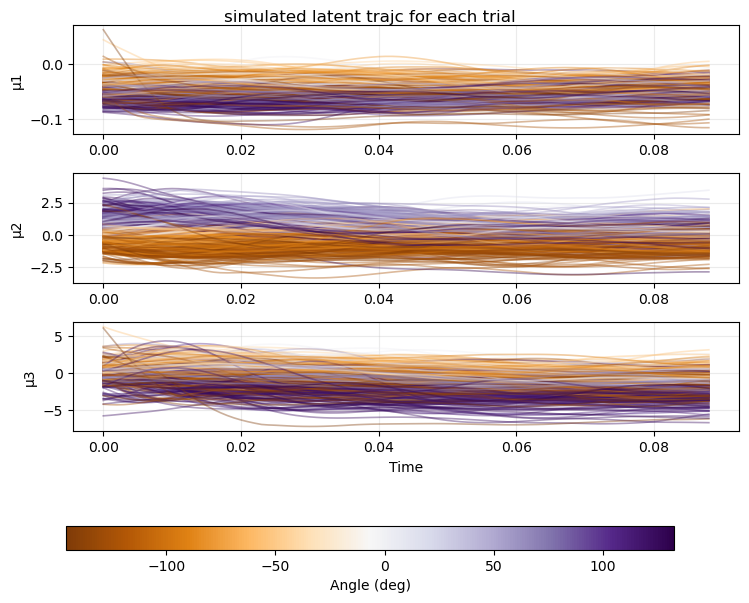

In [26]:
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('simulated latent trajc for each trial')

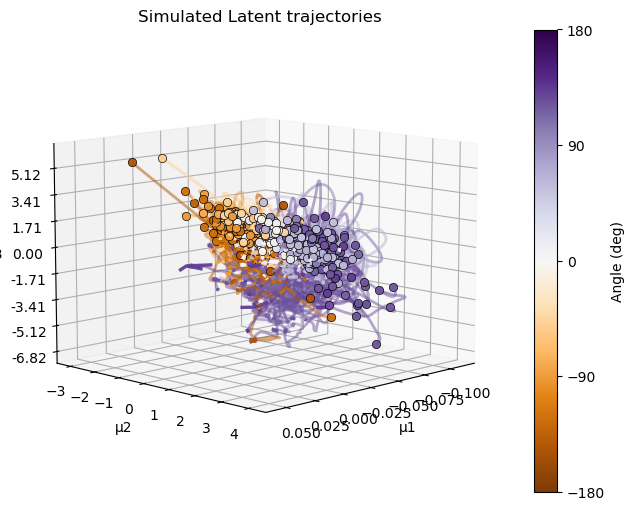

In [27]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_sim_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (10,45), # (20,45)
)

Text(0.5, 0.98, 'simulated mean latent trajc over target location, all dim_preserve')

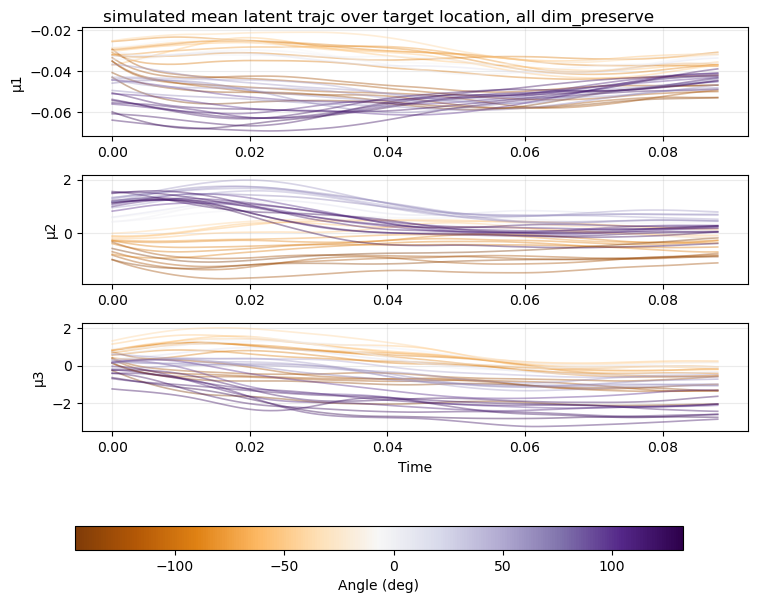

In [28]:
plot_latent_time_series(mean_traj_list_sim, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique, cont_cmap=colorgrad)
plt.suptitle('simulated mean latent trajc over target location, all dim_preserve')

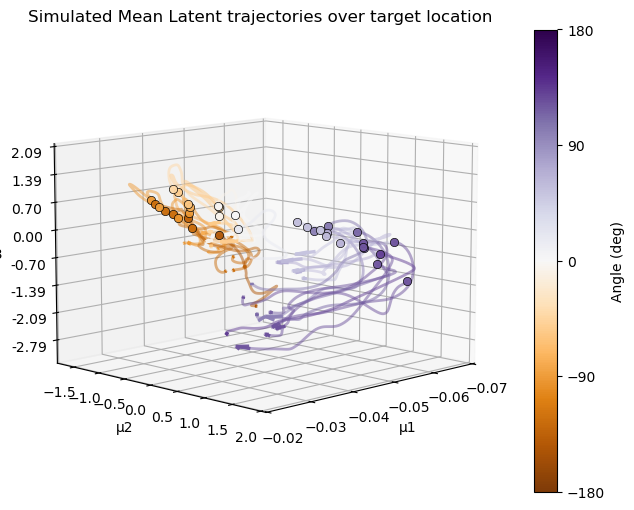

In [29]:
plot_mu_trajectories_gradient_steps_3d(
    mean_traj_list_sim,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_sim)), 
    dims=(0,1,2),
    title="Simulated Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (10,45), # (20,45)
)

## 5.2 Flowed/ Projected

In [30]:
latent_traj_list = proj_to_latent(dset_samples_use, flow_net_use, 0.0, device)
mu_traj_flow = latent_mu(latent_traj_list, encoder_use, dim_preserve, device)
mu_traj_flow_np = [mu_traj_flow[j][start_plot:,:].cpu().numpy() for j in range(len(mu_traj_flow))]

loc_unique, _, mean_traj_flow, _ = mean_traj_by_labels(np.array(mu_traj_flow_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_flow = list(mean_traj_flow)

100%|█████████████████████████████████████████| 592/592 [00:11<00:00, 51.74it/s]


Text(0.5, 0.98, 'flowed latent trajc for each trial, all dim_preserve')

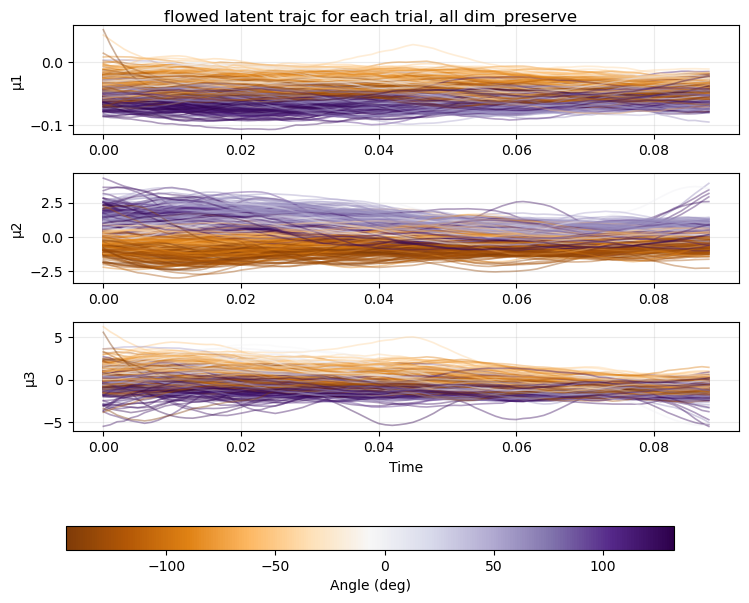

In [31]:
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('flowed latent trajc for each trial, all dim_preserve')

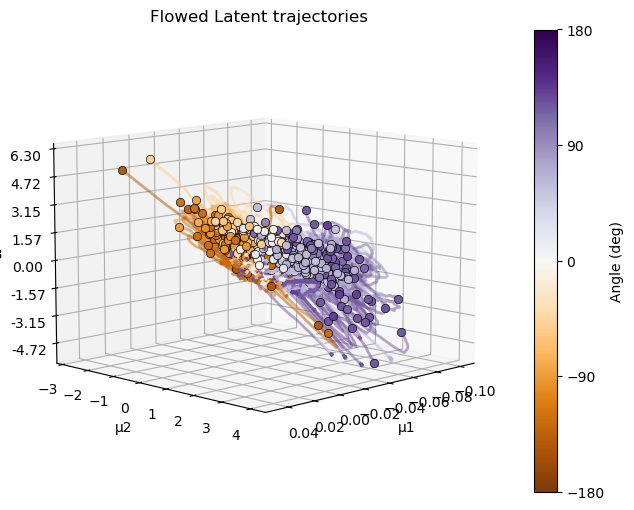

In [32]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_flow_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_flow_np)), 
    dims=(0,1,2),
    title="Flowed Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (10,45), # (20,45)
)

Text(0.5, 0.98, 'flowed mean latent trajc over target location, all dim_preserve')

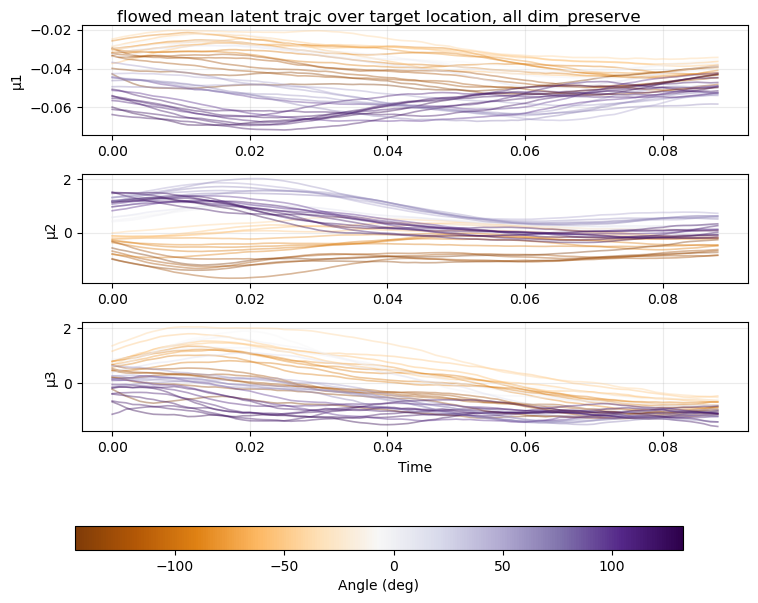

In [33]:
plot_latent_time_series(mean_traj_list_flow, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique, cont_cmap=colorgrad)
plt.suptitle('flowed mean latent trajc over target location, all dim_preserve')

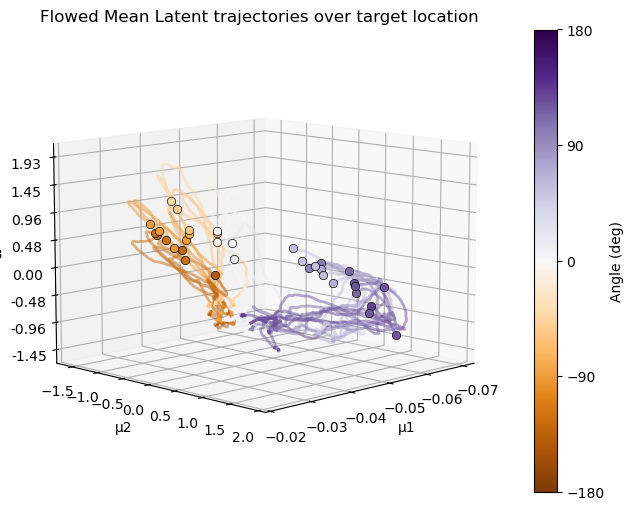

In [34]:
plot_mu_trajectories_gradient_steps_3d(
    mean_traj_list_flow,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_flow)), 
    dims=(0,1,2),
    title="Flowed Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (10,45), # (20,45)
)